## 7 — Ethics, Bias, and Error Analysis (Sprint)

### Objective
This notebook analyzes **systematic error patterns** and **ethical implications** of neighborhood-level crime intensity prediction.

This is **not** a deployment project. The goal is to understand:
- where the model performs worse,
- whether errors differ across neighborhood subgroups,
- and which limitations/risks must be communicated in a master thesis.

Primary framing:
- unit of analysis = **neighborhoods** (areas), not individuals
- predictions are **predictive**, not causal
- registered crime reflects both **crime occurrence** and **reporting/enforcement practices**


## 2. Imports and configuration


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("datasets")
OUT_DIR = Path("outputs") / "ethics_bias_error_analysis"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


## 3. Load model predictions and model-ready data


In [2]:
def pick_prediction_file() -> Path:
    # Priority order (final thesis reporting uses held-out test predictions)
    candidates = [
        Path("outputs/modeling_improvement/test_set_predictions_all_models.csv"),
        # Fallbacks for legacy runs
        Path("outputs/modeling_improvement/oof_predictions_best_model.csv"),
    ]

    imp_dir = Path("outputs/modeling_improvement")
    if imp_dir.exists():
        for p in sorted(imp_dir.glob("*test*pred*.csv")):
            candidates.append(p)
        for p in sorted(imp_dir.glob("*oof*pred*.csv")):
            candidates.append(p)

    for p in candidates:
        if p.exists():
            return p

    raise FileNotFoundError(
        "No prediction file found. Expected one of: "
        "outputs/modeling_improvement/test_set_predictions_all_models.csv (preferred) "
        "or an OOF predictions file under outputs/modeling_improvement/."
    )


def try_load_best_model_info() -> Dict[str, str]:
    p = Path("outputs/modeling_improvement/final_model_comparison.csv")
    if not p.exists():
        return {}
    df = pd.read_csv(p)
    if df.empty:
        return {}
    best = df.sort_values("mean_val_RMSE").iloc[0].to_dict()
    return {
        "best_model": str(best.get("model")),
        "best_dataset_type": str(best.get("dataset_type")),
        "best_tuning_status": str(best.get("tuning_status")),
    }

PREDICTION_FILE = pick_prediction_file()
info = try_load_best_model_info()

print("Using prediction file:", PREDICTION_FILE)
print("Best model info (if available):", info)

preds = pd.read_csv(PREDICTION_FILE)
print("Predictions shape:", preds.shape)
print("Predictions columns:", preds.columns.tolist())

# Load corresponding dataset split for joining context columns
# If we are using test predictions, join against the TEST split; otherwise fall back to full.
base_test_path = DATA_DIR / "model_ready_base_test.csv"
spatial_test_path = DATA_DIR / "model_ready_spatial_test.csv"

base_full_path = DATA_DIR / "model_ready_base.csv"
spatial_full_path = DATA_DIR / "model_ready_spatial.csv"

is_test_preds = "test" in str(PREDICTION_FILE).lower()

if info.get("best_dataset_type", "").lower() == "spatial":
    preferred = spatial_test_path if is_test_preds else spatial_full_path
    fallback = spatial_full_path
else:
    preferred = base_test_path if is_test_preds else base_full_path
    fallback = base_full_path

data_path = preferred if preferred.exists() else fallback
model_df = pd.read_csv(data_path, low_memory=False)
print("Loaded model dataset:", data_path)
print("model_df shape:", model_df.shape)


Using prediction file: outputs/modeling_improvement/oof_predictions_best_model.csv
Best model info (if available): {'best_model': 'XGB', 'best_dataset_type': 'spatial', 'best_tuning_status': 'tuned'}
OOF shape: (14019, 11)
OOF columns: ['gwb_code_10', 'gm_naam', 'population', 'crime_count', 'dataset_type', 'model', 'tuning_status', 'y_true', 'y_pred_oof', 'residual', 'abs_error']
Loaded model dataset: datasets/model_ready_spatial.csv
model_df shape: (14019, 117)


## 4. Identify best model and prediction columns


In [3]:
# Auto-detect columns in the predictions file (test preferred; OOF supported as fallback)
required_candidates = {
    "y_true": ["y_true", "y", "target"],
    "y_pred": ["y_pred", "y_pred_oof", "pred", "prediction"],
}

def pick_col(df: pd.DataFrame, options: List[str]) -> Optional[str]:
    for c in options:
        if c in df.columns:
            return c
    return None

Y_TRUE_COL = pick_col(preds, required_candidates["y_true"])
Y_PRED_COL = pick_col(preds, required_candidates["y_pred"])

if Y_TRUE_COL is None or Y_PRED_COL is None:
    raise ValueError(f"Could not identify y_true/y_pred columns in {PREDICTION_FILE}")

# Identify an ID column for joining (prefer gwb_code_10)
ID_COL = "gwb_code_10" if "gwb_code_10" in preds.columns and "gwb_code_10" in model_df.columns else None
if ID_COL is None and len(preds) != len(model_df):
    raise ValueError("Cannot join predictions to model_df: no shared ID column and row counts differ")

print("Detected y_true column:", Y_TRUE_COL)
print("Detected y_pred column:", Y_PRED_COL)
print("Join ID column:", ID_COL)

keep_pred_cols = [
    c
    for c in [ID_COL, "gm_naam", "dataset_type", "model", "tuning_status", Y_TRUE_COL, Y_PRED_COL]
    if c and c in preds.columns
]
preds_small = preds[keep_pred_cols].copy()

# Merge (if ID col exists) else assume same order
if ID_COL is not None:
    df = model_df.merge(preds_small, on=ID_COL, how="inner", validate="1:1")
else:
    df = model_df.copy()
    for c in keep_pred_cols:
        if c in preds_small.columns:
            df[c] = preds_small[c].values

print("Joined analysis df shape:", df.shape)


Detected y_true column: y_true
Detected y_pred column: y_pred_oof
Join ID column: gwb_code_10
Joined analysis df shape: (14019, 123)


## 5. Construct error variables


In [4]:
df = df.copy()

df["y_true"] = pd.to_numeric(df[Y_TRUE_COL], errors="coerce")
df["y_pred"] = pd.to_numeric(df[Y_PRED_COL], errors="coerce")

if df[["y_true","y_pred"]].isna().any().any():
    raise ValueError("NaNs found in y_true/y_pred after coercion")

df["residual"] = df["y_true"] - df["y_pred"]
df["abs_error"] = df["residual"].abs()
df["squared_error"] = df["residual"] ** 2

df["underprediction"] = df["residual"] > 0

df["overprediction"] = df["residual"] < 0

rmse = float(np.sqrt(mean_squared_error(df["y_true"], df["y_pred"])))
mae = float(mean_absolute_error(df["y_true"], df["y_pred"]))
r2 = float(r2_score(df["y_true"], df["y_pred"]))

overall = {
    "n": len(df),
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2,
    "mean_residual": float(df["residual"].mean()),
    "median_abs_error": float(df["abs_error"].median()),
    "pct_underpredicted": float(df["underprediction"].mean() * 100.0),
    "pct_overpredicted": float(df["overprediction"].mean() * 100.0),
}

overall_df = pd.DataFrame([overall])
print(overall_df.to_string(index=False))
overall_df.to_csv(OUT_DIR / "overall_error_metrics.csv", index=False)


    n    RMSE      MAE       R2  mean_residual  median_abs_error  pct_underpredicted  pct_overpredicted
14019 0.54474 0.400524 0.843402       0.001802          0.299625           49.283116          50.716884


## 6. Define subgroup variables


In [5]:
def safe_qcut(s: pd.Series, q: int, labels: bool = False) -> pd.Series:
    s = pd.to_numeric(s, errors='coerce')
    return pd.qcut(s, q, labels=False if not labels else labels, duplicates='drop')

# Target-based
try:
    df['target_decile'] = safe_qcut(df['y_true'], 10)
except Exception:
    df['target_decile'] = np.nan

# Low/medium/high groups (tertiles)
try:
    df['target_group_3'] = pd.qcut(df['y_true'], 3, labels=['low','medium','high'], duplicates='drop')
except Exception:
    df['target_group_3'] = np.nan

# Population-based
if 'population' in df.columns and pd.api.types.is_numeric_dtype(df['population']):
    df['pop_decile'] = safe_qcut(df['population'], 10)
    df['pop_group_3'] = pd.qcut(df['population'], 3, labels=['small','medium','large'], duplicates='drop')
else:
    print('No population column available for subgrouping.')

# Density / urbanization proxies
# Note: we use CBS-provided density feature `bev_dich` (and `ste_oad`), and do not compute a separate pop_density_per_km2.
for cand in ['bev_dich','ste_oad']:
    if cand in df.columns and pd.api.types.is_numeric_dtype(df[cand]):
        df[f'{cand}_decile'] = safe_qcut(df[cand], 10)

# Socio-economic proxy candidates (choose strongest available later)
socio_candidates = ['p_ink_li','p_ink_hi','a_pau','g_pau_km','g_pau_hh','a_soz_ww','a_soz_wb']
SOCIO_COLS = [c for c in socio_candidates if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
print('Available socio-economic proxy columns:', SOCIO_COLS)

# Housing proxy candidates
housing_candidates = ['p_huurw','p_koopw','a_woning','g_wozbag','p_leegsw']
HOUSING_COLS = [c for c in housing_candidates if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
print('Available housing proxy columns:', HOUSING_COLS)

# Spatial / spillover features
SPILL_COLS = [c for c in df.columns if ('queen_lag' in c.lower()) or ('spillover' in c.lower()) or ('lag_mean' in c.lower()) or ('lag_sum' in c.lower())]
print('Spillover-like columns:', SPILL_COLS[:30])


Available socio-economic proxy columns: ['a_pau', 'g_pau_km', 'g_pau_hh']
Available housing proxy columns: ['p_huurw', 'p_koopw', 'a_woning', 'g_wozbag', 'p_leegsw']
Spillover-like columns: ['queen_lag_sum_bev_dich', 'queen_lag_mean_bev_dich', 'queen_lag_sum_g_wozbag', 'queen_lag_mean_g_wozbag', 'queen_lag_sum_p_huurw', 'queen_lag_mean_p_huurw', 'queen_lag_sum_a_soz_wb', 'queen_lag_mean_a_soz_wb', 'queen_lag_sum_a_bedv', 'queen_lag_mean_a_bedv', 'queen_lag_sum_ste_oad', 'queen_lag_mean_ste_oad']


## Group metrics helper


In [6]:
def calculate_group_error_metrics(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    d = df.dropna(subset=[group_col]).copy()
    if d.empty:
        return pd.DataFrame()

    rows = []
    for g, sub in d.groupby(group_col):
        y_true = sub['y_true']
        y_pred = sub['y_pred']
        n = len(sub)

        mae = float(mean_absolute_error(y_true, y_pred))
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

        r2 = np.nan
        if n >= 30 and y_true.nunique() > 1:
            r2 = float(r2_score(y_true, y_pred))

        rows.append({
            group_col: g,
            'n': n,
            'mean_y_true': float(y_true.mean()),
            'mean_y_pred': float(y_pred.mean()),
            'mean_residual': float((y_true - y_pred).mean()),
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'pct_underpredicted': float((sub['underprediction'].mean()) * 100.0),
            'pct_overpredicted': float((sub['overprediction'].mean()) * 100.0),
        })

    out = pd.DataFrame(rows).sort_values('MAE', ascending=False)
    return out


## 7–12. Subgroup stratification analyses


In [7]:
tables = {}

# Target deciles
if 'target_decile' in df.columns:
    t = calculate_group_error_metrics(df, 'target_decile')
    tables['subgroup_error_by_target_decile'] = t
    t.to_csv(OUT_DIR / 'subgroup_error_by_target_decile.csv', index=False)

# Population deciles
if 'pop_decile' in df.columns:
    t = calculate_group_error_metrics(df, 'pop_decile')
    tables['subgroup_error_by_population_decile'] = t
    t.to_csv(OUT_DIR / 'subgroup_error_by_population_decile.csv', index=False)

# Density deciles
for cand in ['bev_dich_decile','ste_oad_decile']:
    if cand in df.columns:
        t = calculate_group_error_metrics(df, cand)
        tables[f'subgroup_error_by_{cand}'] = t
        t.to_csv(OUT_DIR / f'subgroup_error_by_{cand}.csv', index=False)

# Socio-economic proxy: pick first available
if SOCIO_COLS:
    socio = SOCIO_COLS[0]
    df[f'{socio}_decile'] = safe_qcut(df[socio], 10)
    t = calculate_group_error_metrics(df, f'{socio}_decile')
    tables['subgroup_error_by_socioeconomic_proxy'] = t
    t.to_csv(OUT_DIR / 'subgroup_error_by_socioeconomic_proxy.csv', index=False)
    print('Using socio-economic proxy:', socio)
else:
    print('No socio-economic proxy available; skipping.')

# Spillover feature deciles (use first spillover column as proxy)
if SPILL_COLS:
    spill = SPILL_COLS[0]
    df[f'{spill}_decile'] = safe_qcut(df[spill], 10)
    t = calculate_group_error_metrics(df, f'{spill}_decile')
    tables['subgroup_error_by_spillover_proxy'] = t
    t.to_csv(OUT_DIR / 'subgroup_error_by_spillover_proxy.csv', index=False)
    print('Using spillover proxy:', spill)
else:
    print('No spillover columns available; skipping.')

# Municipality-level
if 'gm_naam' in df.columns:
    gm = calculate_group_error_metrics(df, 'gm_naam')
    tables['municipality_error_summary'] = gm
    gm.to_csv(OUT_DIR / 'municipality_error_summary.csv', index=False)


Using socio-economic proxy: a_pau
Using spillover proxy: queen_lag_sum_bev_dich


## 16. Thesis-ready figures and tables


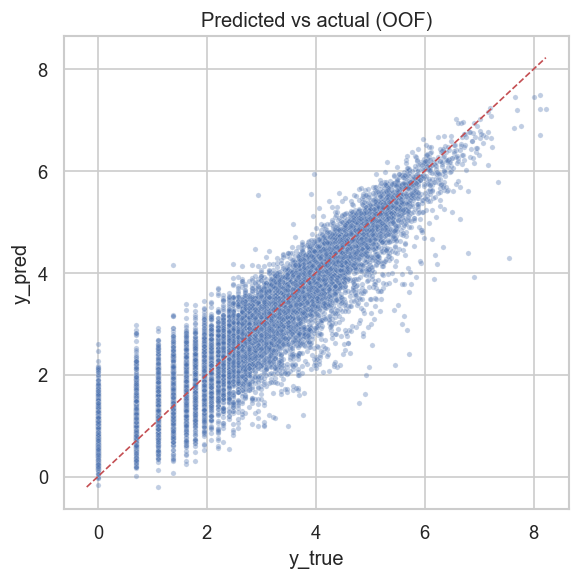

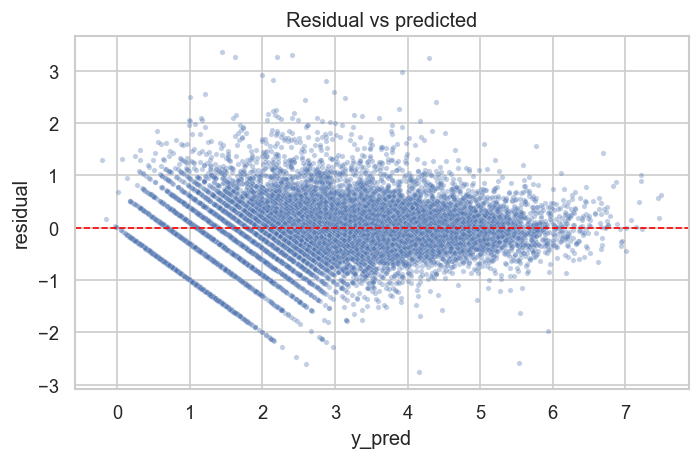

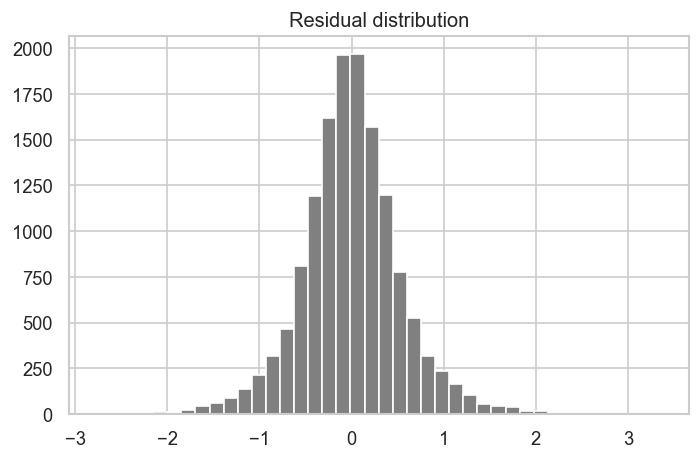

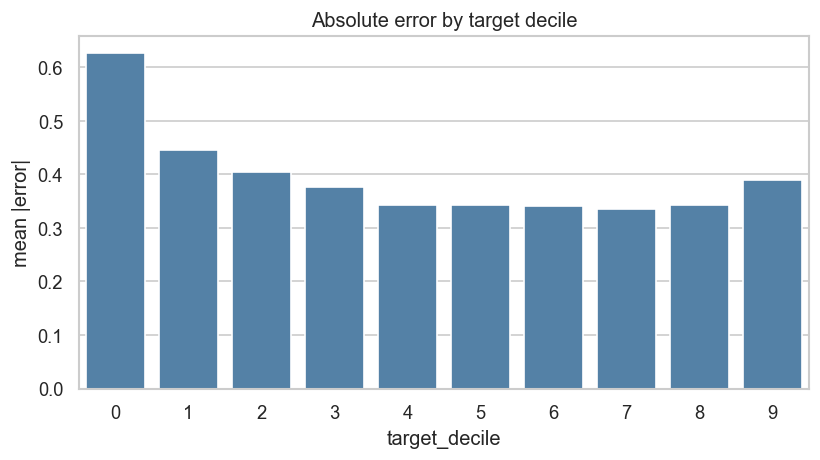

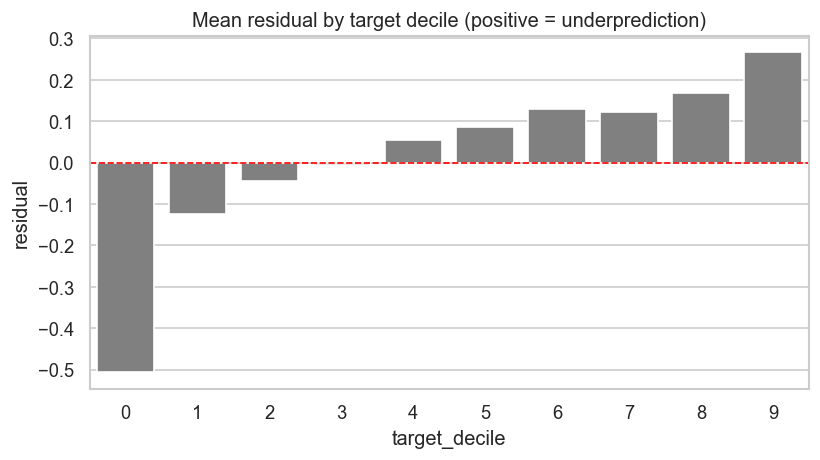

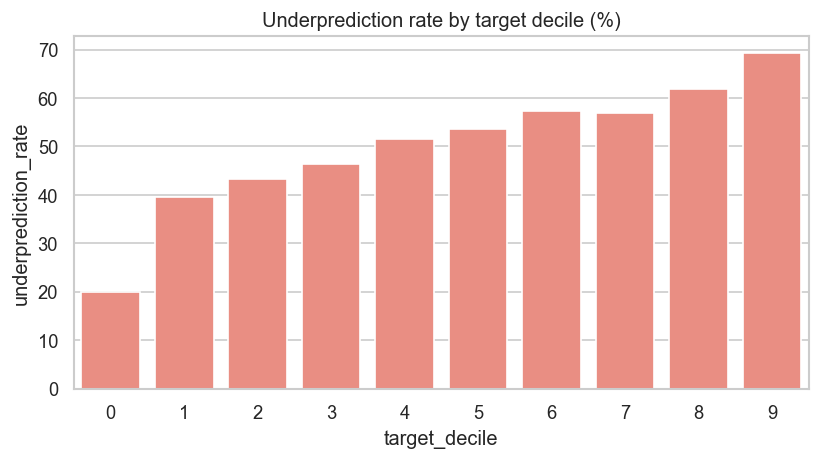

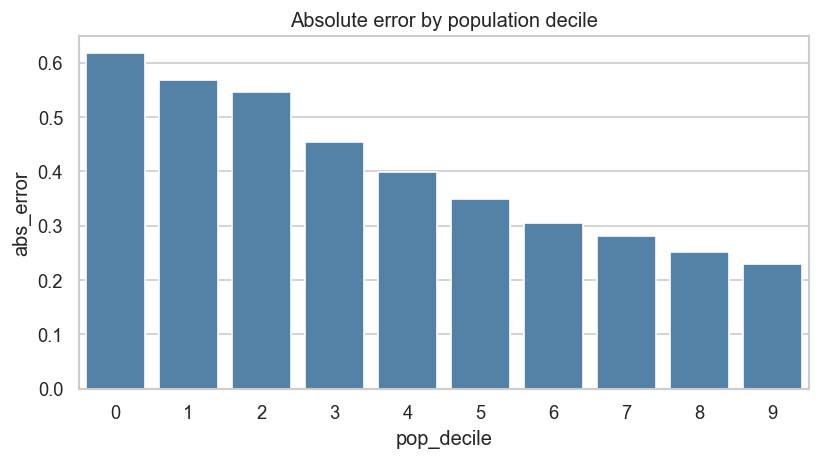

In [8]:
# 1 Pred vs actual
plt.figure(figsize=(5,5))
sns.scatterplot(data=df, x='y_true', y='y_pred', s=10, alpha=0.35)
mn = min(df['y_true'].min(), df['y_pred'].min())
mx = max(df['y_true'].max(), df['y_pred'].max())
plt.plot([mn,mx],[mn,mx],'r--',lw=1)
plt.title('Predicted vs actual (OOF)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'pred_vs_actual.png')
plt.show()

# 2 Residual vs predicted
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='y_pred', y='residual', s=10, alpha=0.35)
plt.axhline(0, color='red', ls='--', lw=1)
plt.title('Residual vs predicted')
plt.tight_layout()
plt.savefig(FIG_DIR / 'residual_vs_pred.png')
plt.show()

# 3 Residual histogram
plt.figure(figsize=(6,4))
plt.hist(df['residual'], bins=40, color='gray', edgecolor='white')
plt.title('Residual distribution')
plt.tight_layout()
plt.savefig(FIG_DIR / 'residual_hist.png')
plt.show()

# 4 Abs error by target decile
if 'target_decile' in df.columns:
    by = df.groupby('target_decile')['abs_error'].agg(['mean','count','std']).reset_index()
    plt.figure(figsize=(7,4))
    sns.barplot(data=by, x='target_decile', y='mean', color='steelblue')
    plt.title('Absolute error by target decile')
    plt.ylabel('mean |error|')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'abs_error_by_target_decile.png')
    plt.show()

    # 5 Mean residual by target decile
    by2 = df.groupby('target_decile')['residual'].mean().reset_index()
    plt.figure(figsize=(7,4))
    sns.barplot(data=by2, x='target_decile', y='residual', color='gray')
    plt.axhline(0, color='red', ls='--', lw=1)
    plt.title('Mean residual by target decile (positive = underprediction)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'mean_residual_by_target_decile.png')
    plt.show()

    # 9 Underprediction rate by target decile
    by3 = df.groupby('target_decile')['underprediction'].mean().reset_index()
    by3['underprediction_rate'] = by3['underprediction'] * 100
    plt.figure(figsize=(7,4))
    sns.barplot(data=by3, x='target_decile', y='underprediction_rate', color='salmon')
    plt.title('Underprediction rate by target decile (%)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'underprediction_rate_by_target_decile.png')
    plt.show()

# 6 Abs error by population decile
if 'pop_decile' in df.columns:
    byp = df.groupby('pop_decile')['abs_error'].mean().reset_index()
    plt.figure(figsize=(7,4))
    sns.barplot(data=byp, x='pop_decile', y='abs_error', color='steelblue')
    plt.title('Absolute error by population decile')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'abs_error_by_population_decile.png')
    plt.show()

# 10 Top 20 municipalities by MAE
if 'gm_naam' in df.columns:
    gm = df.groupby('gm_naam')['abs_error'].mean().sort_values(ascending=False).head(20).reset_index()
    plt.figure(figsize=(8,6))
    sns.barplot(data=gm, y='gm_naam', x='abs_error', color='gray')
    plt.title('Top 20 municipalities by mean absolute error')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'top20_municipalities_by_mae.png')
    plt.show()


## 12–14. Fairness, proxy-risk analysis, and failure mode flags


In [9]:
flags = []

# High-crime underprediction: mean residual in top target decile > 0
if 'target_decile' in df.columns:
    top_dec = df[df['target_decile'] == df['target_decile'].max()]
    if len(top_dec) > 0:
        mr = float(top_dec['residual'].mean())
        if mr > 0:
            flags.append({
                'issue': 'High-crime underprediction',
                'evidence': f'mean residual in top target decile = {mr:.4f} (>0)',
                'interpretation': 'Model tends to underpredict high-intensity neighborhoods (systematic error pattern).'
            })

# Low-population instability
if 'pop_decile' in df.columns:
    low = df[df['pop_decile'] == df['pop_decile'].min()]
    if len(low) > 0:
        low_mae = float(low['abs_error'].mean())
        if low_mae > overall['MAE'] * 1.25:
            flags.append({
                'issue': 'Low-population instability',
                'evidence': f'low-pop MAE = {low_mae:.4f} vs overall MAE = {overall["MAE"]:.4f}',
                'interpretation': 'Model errors are substantially larger in small-population neighborhoods.'
            })

# Socio-economic disparity proxy
if SOCIO_COLS:
    socio = SOCIO_COLS[0]
    try:
        df['_socio_dec'] = safe_qcut(df[socio], 10)
        low_s = df[df['_socio_dec'] == df['_socio_dec'].max()]  # depends on variable meaning; treat as high-proxy group
        if len(low_s) > 0:
            mae_s = float(low_s['abs_error'].mean())
            if mae_s > overall['MAE'] * 1.15:
                flags.append({
                    'issue': 'Socio-economic differential error',
                    'evidence': f'high-{socio} decile MAE = {mae_s:.4f} vs overall MAE = {overall["MAE"]:.4f}',
                    'interpretation': 'Possible differential performance across socio-economic proxy groups; discuss proxy-risk.'
                })
    except Exception:
        pass

# Spillover weakness proxy
if SPILL_COLS:
    spill = SPILL_COLS[0]
    try:
        df['_spill_dec'] = safe_qcut(df[spill], 10)
        high_sp = df[df['_spill_dec'] == df['_spill_dec'].max()]
        if len(high_sp) > 0:
            mae_sp = float(high_sp['abs_error'].mean())
            if mae_sp > overall['MAE'] * 1.15:
                flags.append({
                    'issue': 'Spatial/contextual weakness (spillover proxy)',
                    'evidence': f'high-{spill} decile MAE = {mae_sp:.4f} vs overall MAE = {overall["MAE"]:.4f}',
                    'interpretation': 'Errors are higher in high-spillover contexts; spatial context may be insufficiently captured.'
                })
    except Exception:
        pass

flags_df = pd.DataFrame(flags)
print(flags_df.to_string(index=False) if not flags_df.empty else 'No automatic flags triggered.')
flags_df.to_csv(OUT_DIR / 'flagged_bias_error_patterns.csv', index=False)


                     issue                                         evidence                                                                       interpretation
High-crime underprediction mean residual in top target decile = 0.2664 (>0) Model tends to underpredict high-intensity neighborhoods (systematic error pattern).
Low-population instability     low-pop MAE = 0.6175 vs overall MAE = 0.4005             Model errors are substantially larger in small-population neighborhoods.


## 15. Ethics checklist tailored to this thesis


In [10]:
checklist_rows = [
    # Data collection
    {
        'Area': 'Data collection',
        'Question': 'Could registered crime data reflect reporting or enforcement bias?',
        'Relevance to this thesis': 'High',
        'Current answer / action': 'Discuss as a limitation; interpret predictions as registered crime intensity (not true crime).',
        'Remaining risk': 'High: measurement bias can propagate into models and subgroup error patterns.'
    },
    {
        'Area': 'Data collection',
        'Question': 'Is individual-level personal information used?',
        'Relevance to this thesis': 'Low',
        'Current answer / action': 'No individual PII; unit is neighborhood.',
        'Remaining risk': 'Low.'
    },
    {
        'Area': 'Data collection',
        'Question': 'Are geographic units sufficiently anonymized?',
        'Relevance to this thesis': 'Medium',
        'Current answer / action': 'Neighborhood-level units; still risk of stigmatization via area labeling.',
        'Remaining risk': 'Medium.'
    },
    # Data processing
    {
        'Area': 'Data processing',
        'Question': 'Were zero-population neighborhoods handled transparently?',
        'Relevance to this thesis': 'Medium',
        'Current answer / action': 'Rows excluded from modeling datasets; documented in preprocessing.',
        'Remaining risk': 'Low.'
    },
    {
        'Area': 'Data processing',
        'Question': 'Were missing values handled consistently?',
        'Relevance to this thesis': 'High',
        'Current answer / action': 'Median imputation inside CV pipelines (MVP); report as methodological choice.',
        'Remaining risk': 'Medium: imputation can affect subgroup error.'
    },
    {
        'Area': 'Data processing',
        'Question': 'Were spatial spillover features created without target leakage?',
        'Relevance to this thesis': 'High',
        'Current answer / action': 'Only exogenous predictors were lagged; target-lag columns excluded.',
        'Remaining risk': 'Low–Medium: depends on correctness of exclusion rules.'
    },
    # Analysis
    {
        'Area': 'Analysis',
        'Question': 'Were subgroup errors analyzed?',
        'Relevance to this thesis': 'High',
        'Current answer / action': 'This notebook performs subgroup stratification and flags systematic patterns.',
        'Remaining risk': 'Medium: subgroup definitions are proxies and may be noisy.'
    },
    {
        'Area': 'Analysis',
        'Question': 'Are visualizations honest and not overstating model precision?',
        'Relevance to this thesis': 'High',
        'Current answer / action': 'Use OOF plots, fold stability, and error stratification; avoid causal claims.',
        'Remaining risk': 'Medium.'
    },
    {
        'Area': 'Analysis',
        'Question': 'Is the full pipeline reproducible?',
        'Relevance to this thesis': 'High',
        'Current answer / action': 'Notebook-based pipeline with saved outputs and fixed paths.',
        'Remaining risk': 'Low–Medium (environment differences, e.g., xgboost runtime).'
    },
    # Modeling
    {
        'Area': 'Modeling',
        'Question': 'Could variables act as proxies for socioeconomic disadvantage or protected characteristics?',
        'Relevance to this thesis': 'High',
        'Current answer / action': 'Treat as proxy-risk; analyze differential errors; communicate limitations.',
        'Remaining risk': 'High.'
    },
    {
        'Area': 'Modeling',
        'Question': 'Does performance differ across neighborhood groups?',
        'Relevance to this thesis': 'High',
        'Current answer / action': 'Quantile-based subgroup performance tables + municipality summaries.',
        'Remaining risk': 'Medium.'
    },
    {
        'Area': 'Modeling',
        'Question': 'Were multiple metrics used rather than one single score?',
        'Relevance to this thesis': 'High',
        'Current answer / action': 'RMSE, MAE, R² + residual summaries.',
        'Remaining risk': 'Low.'
    },
    {
        'Area': 'Modeling',
        'Question': 'Can model predictions be explained at a high level?',
        'Relevance to this thesis': 'Medium',
        'Current answer / action': 'Use error stratification + feature importance from previous notebooks.',
        'Remaining risk': 'Medium.'
    },
    # Deployment
    {
        'Area': 'Deployment / real-world use',
        'Question': 'Should the model be used for policing deployment?',
        'Relevance to this thesis': 'High',
        'Current answer / action': 'No: academic analysis only; caution against operational use without safeguards.',
        'Remaining risk': 'High if misused.'
    },
    {
        'Area': 'Deployment / real-world use',
        'Question': 'What safeguards would be needed before real-world use?',
        'Relevance to this thesis': 'High',
        'Current answer / action': 'Transparency, audits, human oversight, bias monitoring, clear scope limits.',
        'Remaining risk': 'High.'
    },
    {
        'Area': 'Deployment / real-world use',
        'Question': 'How should limitations be communicated?',
        'Relevance to this thesis': 'High',
        'Current answer / action': 'Registered-crime measurement bias; predictive not causal; subgroup instability.',
        'Remaining risk': 'Medium.'
    },
    {
        'Area': 'Deployment / real-world use',
        'Question': 'What unintended uses should be avoided?',
        'Relevance to this thesis': 'High',
        'Current answer / action': 'Stigmatization, punitive resource allocation, automated decision-making.',
        'Remaining risk': 'High.'
    },
]

checklist = pd.DataFrame(checklist_rows)
checklist.to_csv(OUT_DIR / 'ethics_checklist.csv', index=False)
print(checklist.to_string(index=False))


                       Area                                                                                    Question Relevance to this thesis                                                                        Current answer / action                                                                Remaining risk
            Data collection                          Could registered crime data reflect reporting or enforcement bias?                     High Discuss as a limitation; interpret predictions as registered crime intensity (not true crime). High: measurement bias can propagate into models and subgroup error patterns.
            Data collection                                              Is individual-level personal information used?                      Low                                                       No individual PII; unit is neighborhood.                                                                          Low.
            Data collection                   

## Sprint ethics answers

This section should be written using the numeric outputs produced above (overall metrics, subgroup tables, flagged patterns, and figures).

Questions to answer:
1. How does performance differ across subgroups?
2. Where does the model fail most?
3. Does the model systematically underpredict or overpredict any group?
4. Are high-crime neighborhoods harder to predict?
5. Are low-population neighborhoods harder to predict?
6. Are errors associated with socioeconomic disadvantage?
7. What fairness or bias concerns emerged?
8. What do these results imply for generalizability?
9. Are the errors acceptable for real-world use?
10. How should these limitations be communicated in the thesis?


## 18. Save outputs

All outputs are written to:
- `outputs/ethics_bias_error_analysis/`
- `outputs/ethics_bias_error_analysis/figures/`
